<a href="https://colab.research.google.com/github/EduardoZamora03/Proyecto-samsung/blob/main/Proyecto_samsung_Limpieza_de_datos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

In [ ]:
dataset = pd.read_csv('RT_IOT2022_formateado.csv')
dataset.head()

,Unnamed: 0,id.orig_p,id.resp_p,proto,service,flow_duration,fwd_pkts_tot,bwd_pkts_tot,fwd_data_pkts_tot,bwd_data_pkts_tot,...,active.std,idle.min,idle.max,idle.tot,idle.avg,idle.std,fwd_init_window_size,bwd_init_window_size,fwd_last_window_size,Attack_type
0,0,38667,1883,tcp,mqtt,32.011598,9,5,3,3,...,0.0,2.972918e+07,2.972918e+07,2.972918e+07,2.972918e+07,0.0,64240,26847,502,MQTT_Publish
1,1,51143,1883,tcp,mqtt,31.883584,9,5,3,3,...,0.0,2.985528e+07,2.985528e+07,2.985528e+07,2.985528e+07,0.0,64240,26847,502,MQTT_Publish
2,2,44761,1883,tcp,mqtt,32.124053,9,5,3,3,...,0.0,2.984215e+07,2.984215e+07,2.984215e+07,2.984215e+07,0.0,64240,26847,502,MQTT_Publish
3,3,60893,1883,tcp,mqtt,31.961063,9,5,3,3,...,0.0,2.991377e+07,2.991377e+07,2.991377e+07,2.991377e+07,0.0,64240,26847,502,MQTT_Publish
4,4,51087,1883,tcp,mqtt,31.902362,9,5,3,3,...,0.0,2.981470e+07,2.981470e+07,2.981470e+07,2.981470e+07,0.0,64240,26847,502,MQTT_Publish


In [ ]:
dataset.info()
dataset.describe()
dataset.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 123117 entries, 0 to 123116
Data columns (total 85 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   Unnamed: 0                123117 non-null  int64  
 1   id.orig_p                 123117 non-null  int64  
 2   id.resp_p                 123117 non-null  int64  
 3   proto                     123117 non-null  object 
 4   service                   123117 non-null  object 
 5   flow_duration             123117 non-null  float64
 6   fwd_pkts_tot              123117 non-null  int64  
 7   bwd_pkts_tot              123117 non-null  int64  
 8   fwd_data_pkts_tot         123117 non-null  int64  
 9   bwd_data_pkts_tot         123117 non-null  int64  
 10  fwd_pkts_per_sec          123117 non-null  float64
 11  bwd_pkts_per_sec          123117 non-null  float64
 12  flow_pkts_per_sec         123117 non-null  float64
 13  down_up_ratio             123117 non-null  f

(123117, 85)

In [ ]:
dataset.shape

(123117, 85)

In [ ]:
#Limpieza del dataset
if 'Unnamed: 0' in dataset.columns:
  dataset = dataset.drop(columns=['Unnamed: 0'])

#Se elimina datos repetidos
dataset = dataset.drop_duplicates()

#Se elimina valores infinitos
numeric_cols = dataset.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
  if np.isinf(dataset[col]).any():
    max_val = dataset.loc[np.isfinite(dataset[col])].max()
    dataset[col] = dataset[col].replace([np.inf, -np.inf], max_val)

#Limpieza de datos NaN
for col in dataset.columns:
    if dataset[col].isnull().any():
        if dataset[col].dtype == 'object':
            dataset[col] = dataset[col].fillna('unknown')
        else:
            dataset[col] = dataset[col].fillna(0)

print(dataset)
#dataset.to_csv('RT_IOT2022_limpio.csv', index=False)

        id.orig_p  id.resp_p proto service  flow_duration  fwd_pkts_tot  \
0           38667       1883   tcp    mqtt      32.011598             9   
1           51143       1883   tcp    mqtt      31.883584             9   
2           44761       1883   tcp    mqtt      32.124053             9   
3           60893       1883   tcp    mqtt      31.961063             9   
4           51087       1883   tcp    mqtt      31.902362             9   
...           ...        ...   ...     ...            ...           ...   
123112      59247      63331   tcp       -       0.000006             1   
123113      59247      64623   tcp       -       0.000007             1   
123114      59247      64680   tcp       -       0.000006             1   
123115      59247      65000   tcp       -       0.000006             1   
123116      59247      65129   tcp       -       0.000006             1   

        bwd_pkts_tot  fwd_data_pkts_tot  bwd_data_pkts_tot  fwd_pkts_per_sec  \
0                  

In [ ]:
#Eliminamos las columnas id.orig_p, id.resp_p
columnas_a_eliminar = ['id.orig_p', 'id.resp_p']
dataset = dataset.drop(columns=[col for col in columnas_a_eliminar if col in dataset.columns])

#Conversion de datos TCP y UDP, los dividimos en varias columnas (1 = si; 0 = no)
columnas_categoricas = ['proto', 'service']
columnas_a_codificar = [col for col in columnas_categoricas if col in dataset.columns]
dataset = pd.get_dummies(dataset, columns=columnas_a_codificar, dtype = int)
dataset
#dataset_codificado.to_csv('RT_IOT2022_codificado.csv', index=False)

,flow_duration,fwd_pkts_tot,bwd_pkts_tot,fwd_data_pkts_tot,bwd_data_pkts_tot,fwd_pkts_per_sec,bwd_pkts_per_sec,flow_pkts_per_sec,down_up_ratio,fwd_header_size_tot,...,service_-,service_dhcp,service_dns,service_http,service_irc,service_mqtt,service_ntp,service_radius,service_ssh,service_ssl
0,32.011598,9,5,3,3,0.281148,0.156193,0.437341,0.555556,296,...,0,0,0,0,0,1,0,0,0,0
1,31.883584,9,5,3,3,0.282277,0.156821,0.439097,0.555556,296,...,0,0,0,0,0,1,0,0,0,0
2,32.124053,9,5,3,3,0.280164,0.155647,0.435811,0.555556,296,...,0,0,0,0,0,1,0,0,0,0
3,31.961063,9,5,3,3,0.281593,0.156440,0.438033,0.555556,296,...,0,0,0,0,0,1,0,0,0,0
4,31.902362,9,5,3,3,0.282111,0.156728,0.438839,0.555556,296,...,0,0,0,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
123112,0.000006,1,1,0,0,167772.160000,167772.160000,335544.320000,1.000000,20,...,1,0,0,0,0,0,0,0,0,0
123113,0.000007,1,1,0,0,144631.172414,144631.172414,289262.344828,1.000000,20,...,1,0,0,0,0,0,0,0,0,0
123114,0.000006,1,1,0,0,167772.160000,167772.160000,335544.320000,1.000000,20,...,1,0,0,0,0,0,0,0,0,0
123115,0.000006,1,1,0,0,167772.160000,167772.160000,335544.320000,1.000000,20,...,1,0,0,0,0,0,0,0,0,0


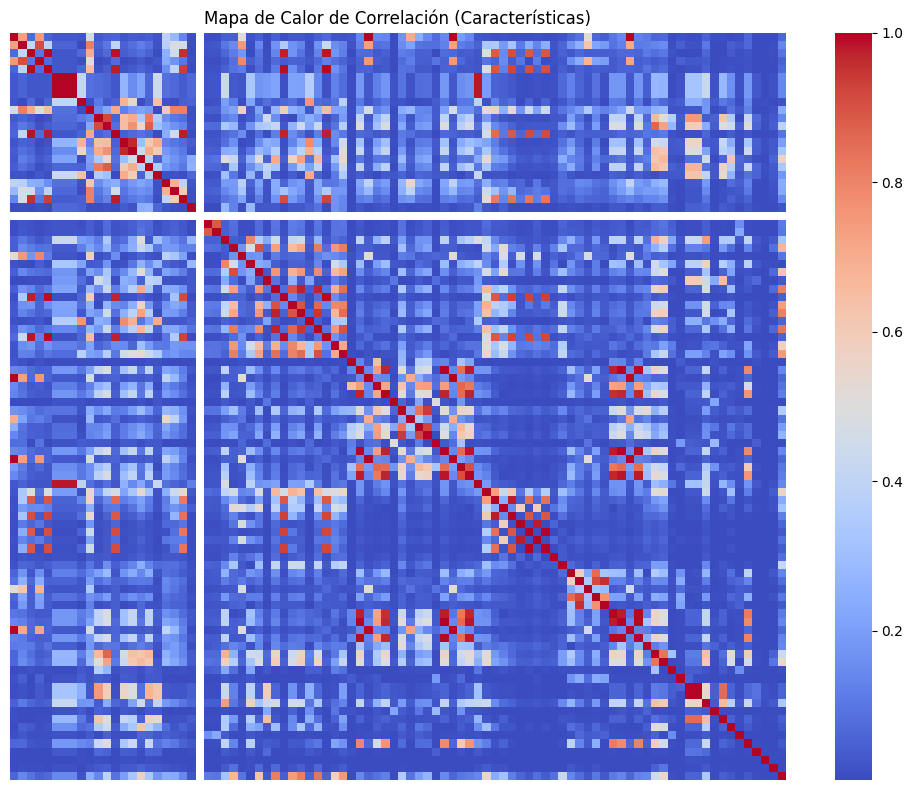

Columnas eliminadas: ['bwd_data_pkts_tot', 'bwd_pkts_per_sec', 'flow_pkts_per_sec', 'bwd_pkts_payload.tot', 'flow_pkts_payload.tot', 'fwd_iat.tot', 'flow_iat.max', 'flow_iat.tot', 'bwd_bulk_packets', 'idle.max', 'idle.tot', 'idle.avg', 'proto_udp']
Anterior tamaño: (117922, 93)
Nuevo tamaño: (117922, 80)


,flow_duration,fwd_pkts_tot,bwd_pkts_tot,fwd_data_pkts_tot,fwd_pkts_per_sec,down_up_ratio,fwd_header_size_tot,fwd_header_size_min,fwd_header_size_max,bwd_header_size_tot,...,service_-,service_dhcp,service_dns,service_http,service_irc,service_mqtt,service_ntp,service_radius,service_ssh,service_ssl
0,32.011598,9,5,3,0.281148,0.555556,296,32,40,168,...,0,0,0,0,0,1,0,0,0,0
1,31.883584,9,5,3,0.282277,0.555556,296,32,40,168,...,0,0,0,0,0,1,0,0,0,0
2,32.124053,9,5,3,0.280164,0.555556,296,32,40,168,...,0,0,0,0,0,1,0,0,0,0
3,31.961063,9,5,3,0.281593,0.555556,296,32,40,168,...,0,0,0,0,0,1,0,0,0,0
4,31.902362,9,5,3,0.282111,0.555556,296,32,40,168,...,0,0,0,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
123112,0.000006,1,1,0,167772.160000,1.000000,20,20,20,20,...,1,0,0,0,0,0,0,0,0,0
123113,0.000007,1,1,0,144631.172414,1.000000,20,20,20,20,...,1,0,0,0,0,0,0,0,0,0
123114,0.000006,1,1,0,167772.160000,1.000000,20,20,20,20,...,1,0,0,0,0,0,0,0,0,0
123115,0.000006,1,1,0,167772.160000,1.000000,20,20,20,20,...,1,0,0,0,0,0,0,0,0,0


In [ ]:
#Seleccion de caracteristicas
if 'Attack_type' in dataset.columns:
  dataset_numerico = dataset.drop(columns=['Attack_type'])
else:
  dataset_numerico = dataset.copy()

#Matriz de correlacion
correlacion = dataset_numerico.corr().abs()

#Mapa de calor
plt.figure(figsize=(10, 8))
sns.heatmap(correlacion, cmap='coolwarm', xticklabels=False, yticklabels=False)
plt.title('Mapa de Calor de Correlación (Características)')
plt.tight_layout()
plt.show()

#Seleccionamos el triángulo superior de la matriz de correlación para no comparar la misma variable dos veces
upper = correlacion.where(np.triu(np.ones(correlacion.shape), k=1).astype(bool))

#Se eliminan columnas con una correlacion mayor a 0.99
columnas_a_eliminar = [columna for columna in upper.columns if any(upper[columna] > 0.99)] #Se elimina la columna del protocolo udp, como son solo dos protocolos udp y tcp, si es 1=tcp, 0=udp
print(f"Columnas eliminadas: {columnas_a_eliminar}") #Proto_icmp = paquete de datos enviado como un pingeo

dataset_correlacion = dataset.drop(columns=columnas_a_eliminar)
print(f"Anterior tamaño: {dataset.shape}")
print(f"Nuevo tamaño: {dataset_correlacion.shape}")
dataset_correlacion

In [ ]:
#Normalizacion y escalado

#Separamos la variable objetivo del dataset
Target_regresion = 'flow_duration'

if Target_regresion in dataset_correlacion.columns:
  target = dataset_correlacion[Target_regresion]
  dataset_features = dataset_correlacion.drop(columns=[Target_regresion, 'Attack_type'], errors = 'ignore') #Eliminamos attack type ya que es una columna de tipo caracteres y la variable objetivo de la regresion
else:
  raise ValueError(f"La columna '{Target_regresion}' no se encuentra en el DataFrame.")

#Se inicia el escalador
scaler = StandardScaler()
columnas  = dataset_features.columns
datos_escalados = scaler.fit_transform(dataset_features)
dataset_escalado = pd.DataFrame(datos_escalados, columns=columnas)

#Aqui se almacena para clustering, sin la variable objetivo
dataset_escalado.to_csv('RT_IOT2022_clustering.csv', index=False) #Datos limpios, estandarizados y sin la variable objetivo

dataset_escalado[Target_regresion] = target.values

dataset_escalado.to_csv('RT_IOT2022_regresion.csv', index=False) #Datos limpios, estandarizados, sin balanceo
dataset_escalado

,fwd_pkts_tot,bwd_pkts_tot,fwd_data_pkts_tot,fwd_pkts_per_sec,down_up_ratio,fwd_header_size_tot,fwd_header_size_min,fwd_header_size_max,bwd_header_size_tot,bwd_header_size_min,...,service_dhcp,service_dns,service_http,service_irc,service_mqtt,service_ntp,service_radius,service_ssh,service_ssl,flow_duration
0,0.303454,0.090645,0.079306,-0.947016,-0.889348,0.605784,2.271009,2.649994,0.114615,1.782523,...,-0.015684,-0.295058,-0.169386,-0.015411,5.247735,-0.031244,-0.004118,-0.015411,-0.151797,32.011598
1,0.303454,0.090645,0.079306,-0.947016,-0.889348,0.605784,2.271009,2.649994,0.114615,1.782523,...,-0.015684,-0.295058,-0.169386,-0.015411,5.247735,-0.031244,-0.004118,-0.015411,-0.151797,31.883584
2,0.303454,0.090645,0.079306,-0.947016,-0.889348,0.605784,2.271009,2.649994,0.114615,1.782523,...,-0.015684,-0.295058,-0.169386,-0.015411,5.247735,-0.031244,-0.004118,-0.015411,-0.151797,32.124053
3,0.303454,0.090645,0.079306,-0.947016,-0.889348,0.605784,2.271009,2.649994,0.114615,1.782523,...,-0.015684,-0.295058,-0.169386,-0.015411,5.247735,-0.031244,-0.004118,-0.015411,-0.151797,31.961063
4,0.303454,0.090645,0.079306,-0.947016,-0.889348,0.605784,2.271009,2.649994,0.114615,1.782523,...,-0.015684,-0.295058,-0.169386,-0.015411,5.247735,-0.031244,-0.004118,-0.015411,-0.151797,31.902362
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
117917,-0.058350,-0.027953,-0.076248,-0.494437,0.430073,-0.087364,0.041017,-0.091761,-0.026273,0.284104,...,-0.015684,-0.295058,-0.169386,-0.015411,-0.190558,-0.031244,-0.004118,-0.015411,-0.151797,0.000006
117918,-0.058350,-0.027953,-0.076248,-0.556862,0.430073,-0.087364,0.041017,-0.091761,-0.026273,0.284104,...,-0.015684,-0.295058,-0.169386,-0.015411,-0.190558,-0.031244,-0.004118,-0.015411,-0.151797,0.000007
117919,-0.058350,-0.027953,-0.076248,-0.494437,0.430073,-0.087364,0.041017,-0.091761,-0.026273,0.284104,...,-0.015684,-0.295058,-0.169386,-0.015411,-0.190558,-0.031244,-0.004118,-0.015411,-0.151797,0.000006
117920,-0.058350,-0.027953,-0.076248,-0.494437,0.430073,-0.087364,0.041017,-0.091761,-0.026273,0.284104,...,-0.015684,-0.295058,-0.169386,-0.015411,-0.190558,-0.031244,-0.004118,-0.015411,-0.151797,0.000006


In [ ]:
#Balanceo de clases

#X = Caracteristicas; Y = Etiquetas
# Usamos dataset_escalado sin el target de regresion, y agregamos Attack_type para clasificacion
X = dataset_escalado.drop(columns=[Target_regresion], errors='ignore')
y = dataset_correlacion['Attack_type'].values  # Tomamos Attack_type del dataset original

# Creamos el dataset final solo con datos REALES
dataset_limpio = pd.DataFrame(X, columns=X.columns)
dataset_limpio['Attack_type'] = y

#Eliminar duplicados masivos de red de una vez
print(f"Filas antes de borrar duplicados: {len(dataset_limpio)}")
dataset_limpio = dataset_limpio.drop_duplicates()
print(f"Filas reales únicas: {len(dataset_limpio)}")

#NUEVO: Eliminar clases con muestras insuficientes
UMBRAL_MINIMO = 20

conteo_clases = dataset_limpio['Attack_type'].value_counts()
clases_validas = conteo_clases[conteo_clases >= UMBRAL_MINIMO].index
clases_eliminadas = set(conteo_clases.index) - set(clases_validas) #Se llega a eliminar la clase NMPA_FIN_SCAN ya que la cantidad de datos es muy poca lo cual genera problemas para su entrenamiento

if clases_eliminadas:
    print(f"\nClases eliminadas por muestras insuficientes (<{UMBRAL_MINIMO}): {clases_eliminadas}")
    dataset_limpio = dataset_limpio[dataset_limpio['Attack_type'].isin(clases_validas)].copy()
else:
    print(f"\nTodas las clases superan el umbral mínimo de {UMBRAL_MINIMO} muestras.")

print("\nDistribución de datos REALES listos para guardar:")
print(dataset_limpio['Attack_type'].value_counts())
print(f"\nClases finales: {dataset_limpio['Attack_type'].nunique()}")
print(f"Muestras totales: {len(dataset_limpio)}")

# Mezclado de los datos reales
dataset_limpio = dataset_limpio.sample(frac=1, random_state=42).reset_index(drop=True)

dataset_limpio.to_csv('RT_IOT2022_clasificacion_limpio.csv', index=False)
dataset_limpio

Filas antes de borrar duplicados: 117922
Filas reales únicas: 18283

Clases eliminadas por muestras insuficientes (<20): {'NMAP_FIN_SCAN'}

Distribución de datos REALES listos para guardar:
Attack_type
Thing_Speak                   7599
ARP_poisioning                5298
MQTT_Publish                  4141
DDOS_Slowloris                 533
Wipro_bulb                     219
NMAP_UDP_SCAN                  196
NMAP_XMAS_TREE_SCAN             80
NMAP_OS_DETECTION               75
DOS_SYN_Hping                   57
NMAP_TCP_scan                   44
Metasploit_Brute_Force_SSH      36
Name: count, dtype: int64

Clases finales: 11
Muestras totales: 18278


,fwd_pkts_tot,bwd_pkts_tot,fwd_data_pkts_tot,fwd_pkts_per_sec,down_up_ratio,fwd_header_size_tot,fwd_header_size_min,fwd_header_size_max,bwd_header_size_tot,bwd_header_size_min,...,service_dhcp,service_dns,service_http,service_irc,service_mqtt,service_ntp,service_radius,service_ssh,service_ssl,Attack_type
0,0.348680,0.268541,0.183009,-0.946975,0.726943,0.374735,0.041017,0.456590,0.167924,0.284104,...,-0.015684,-0.295058,-0.169386,-0.015411,-0.190558,-0.031244,-0.004118,-0.015411,6.587742,Wipro_bulb
1,0.348680,0.120294,0.079306,-0.947016,-0.757407,0.686149,2.271009,2.649994,0.145077,1.782523,...,-0.015684,-0.295058,-0.169386,-0.015411,5.247735,-0.031244,-0.004118,-0.015411,-0.151797,MQTT_Publish
2,-0.013125,0.001697,0.027455,-0.946757,0.430073,-0.097410,-2.188974,-1.736814,-0.030080,-1.214314,...,-0.015684,3.389166,-0.169386,-0.015411,-0.190558,-0.031244,-0.004118,-0.015411,-0.151797,Thing_Speak
3,-0.013125,0.001697,0.027455,-0.946747,0.430073,-0.097410,-2.188974,-1.736814,-0.030080,-1.214314,...,-0.015684,3.389166,-0.169386,-0.015411,-0.190558,-0.031244,-0.004118,-0.015411,-0.151797,Thing_Speak
4,0.439131,0.209242,0.131157,-0.946852,-0.312102,0.816742,0.041017,2.649994,0.236464,1.782523,...,-0.015684,-0.295058,-0.169386,-0.015411,-0.190558,-0.031244,-0.004118,-0.015411,6.587742,ARP_poisioning
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18273,-0.013125,0.001697,0.027455,-0.946810,0.430073,-0.097410,-2.188974,-1.736814,-0.030080,-1.214314,...,-0.015684,3.389166,-0.169386,-0.015411,-0.190558,-0.031244,-0.004118,-0.015411,-0.151797,Thing_Speak
18274,-0.013125,0.001697,0.027455,-0.945885,0.430073,-0.097410,-2.188974,-1.736814,-0.030080,-1.214314,...,-0.015684,3.389166,-0.169386,-0.015411,-0.190558,-0.031244,-0.004118,-0.015411,-0.151797,ARP_poisioning
18275,-0.013125,0.001697,0.027455,-0.946887,0.430073,-0.097410,-2.188974,-1.736814,-0.030080,-1.214314,...,-0.015684,3.389166,-0.169386,-0.015411,-0.190558,-0.031244,-0.004118,-0.015411,-0.151797,Thing_Speak
18276,0.348680,0.120294,0.079306,-0.947016,-0.757407,0.686149,2.271009,2.649994,0.145077,1.782523,...,-0.015684,-0.295058,-0.169386,-0.015411,5.247735,-0.031244,-0.004118,-0.015411,-0.151797,MQTT_Publish
